# Week 6 Shootout

此作業範例選用2024年7月25日凱米颱風(Typhoon Gaemi)的降雨資料，與2025年7月31日受竹節草颱風(Typhoon Co-May)的資料進行比較分析。在降雨型態上，前者有實際登陸台灣，造成全台廣泛性的大範圍降雨。後者沒有登陸台灣，只在東部外海與北部外海徘徊，但在登陸中國時引進強大的西南氣流，局部性地對中南部造成致災性的超大豪雨。分析的重點在於比較兩次颱風的降雨空間分布特徵，並使用克里金插值法(Kriging)進行空間插值與預測，以了解降雨的空間變異性與極端降雨的分布模式。

📝 **Captain's Log: Phase 1 - 降雨資料設定與坐標系統校準**

載入凱米颱風與竹節草颱風的測站資料，鎖定目標防區為「花蓮縣」與「宜蘭縣」，並剔除雨量為 `-998`（儀器異常）與 `0` 的測站。坐標系統設定為EPSG:3826，以便 Kriging 計算。

In [ ]:
import pandas as pd
import geopandas as gpd

def preprocess_rainfall_data(file_path, target_col='Past24hr'):
    """讀取降雨資料，篩選縣市、取最新時間點，並轉換坐標系為 EPSG:3826。"""
    df = pd.read_csv(file_path)
    df_filtered = df[df['CountyName'].isin(['花蓮縣', '宜蘭縣'])].copy()
    
    # 🚨【邏輯修改】🚨 確保 DateTime 為時間格式，並針對每個測站取得「時間最晚」的那一筆
    df_filtered['DateTime'] = pd.to_datetime(df_filtered['DateTime'])
    idx = df_filtered.groupby('StationId')['DateTime'].idxmax()
    df_filtered = df_filtered.loc[idx].copy()
    
    # 過濾異常值與無雨狀態
    df_filtered = df_filtered[(df_filtered[target_col] != -998) & (df_filtered[target_col] > 0)]
    
    # 建立空間資料並轉換 CRS
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered['StationLongitude'], df_filtered['StationLatitude']),
        crs="EPSG:4326"
    )
    gdf_3826 = gdf.to_crs("EPSG:3826")
    
    # 萃取投影坐標供 RF 使用
    gdf_3826['Easting'] = gdf_3826.geometry.x
    gdf_3826['Northing'] = gdf_3826.geometry.y
    
    return gdf_3826

# ================= 執行區塊 =================
file_2024 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20240725.csv"
file_2025 = r"C:\Users\alvin\Desktop\Analysis and application of Remote sensing & geospatial information\Homework6\data\rain_20250731.csv"
target_column = 'Past24hr' 

# 重新載入並處理兩場事件
gdf_kaemi = preprocess_rainfall_data(file_2024, target_col=target_column)
gdf_bamboo = preprocess_rainfall_data(file_2025, target_col=target_column)

# 基本檢查
print(f"凱米颱風 (2024) 有效測站數量: {len(gdf_kaemi)}")
print(f"竹節草颱風 (2025) 有效測站數量: {len(gdf_bamboo)}")
print("-" * 50)

# ================= 驗證區塊 (六十石山) =================
def verify_station(gdf, station_name, event_name):
    station_data = gdf[gdf['StationName'] == station_name]
    if not station_data.empty:
        time_str = station_data['DateTime'].iloc[0].strftime('%Y-%m-%d %H:%M:%S')
        rain_val = station_data[target_column].iloc[0]
        print(f"✅ {event_name} - {station_name} 測站資訊:")
        print(f"   擷取時間: {time_str}")
        print(f"   {target_column} 雨量: {rain_val} mm")
    else:
        print(f"⚠️ {event_name} 中找不到 {station_name} 測站 (可能無雨或數值異常被過濾)。")

verify_station(gdf_kaemi, '六十石山', '凱米颱風 (2024)')
verify_station(gdf_bamboo, '六十石山', '竹節草颱風 (2025)')

凱米颱風 (2024) 有效測站數量: 150
竹節草颱風 (2025) 有效測站數量: 123


> 📝 **Captain's Log: Phase 2 - 降雨空間結構解析 (Variogram Analysis)**
> 
> **任務目標**：透過計算與繪製半變異圖 (Semivariogram)，捕捉凱米颱風與竹節草颱風降雨的空間自相關性 (Spatial Autocorrelation)，並找出最適合的擬合模型。
> 
> **執行動作 (AI 協助紀錄)**：
> 1. **模型配適**：利用 `pykrige.ok.OrdinaryKriging` 內部引擎，針對兩場颱風的降雨資料 (`Past24hr`)，分別計算實驗半變異量 (Experimental Semivariance)。
> 2. **雙曲線交鋒**：對同一組實驗數據，同時套用 `Spherical` 與 `Exponential` 理論模型進行擬合，以視覺化評估哪個模型更貼合資料趨勢，特別是在短距離 (Lag distance 較小) 的表現。
> 3. **參數萃取**：提取並印出三大關鍵參數：Sill (最大變異量)、Range (空間相關範圍)、Nugget (塊狀效應)，為跨事件比較提供量化依據。

正在處理 2024 凱米颱風...


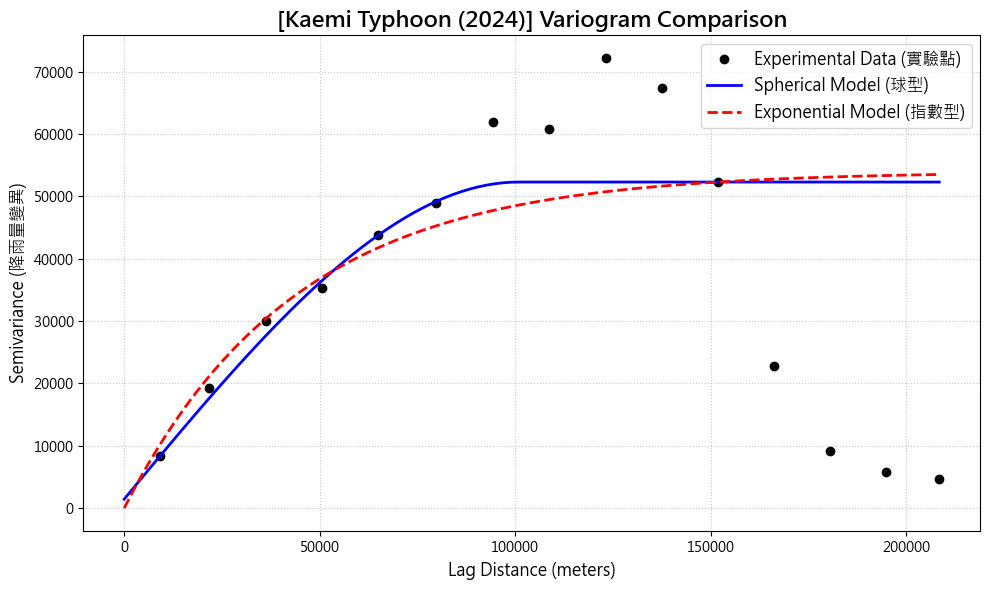

📌 Kaemi Typhoon (2024) - Variogram 參數摘要
[Spherical]   Sill: 50853.12, Range: 100921.91, Nugget: 1448.69
[Exponential] Sill: 53972.08, Range: 131143.97, Nugget: 0.00
------------------------------------------------------------
正在處理 2025 竹節草颱風...


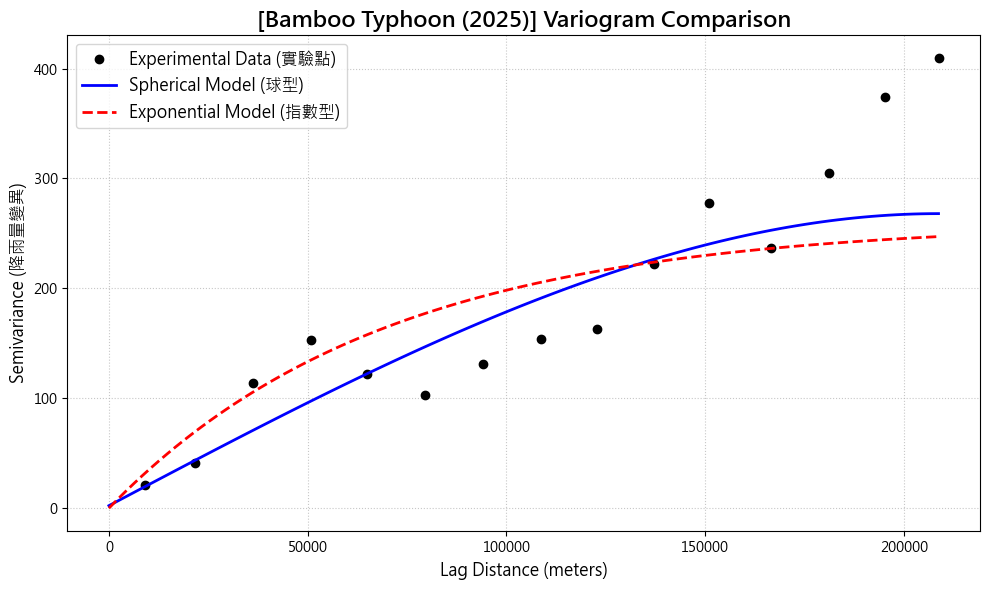

📌 Bamboo Typhoon (2025) - Variogram 參數摘要
[Spherical]   Sill: 265.71, Range: 208725.16, Nugget: 2.30
[Exponential] Sill: 260.06, Range: 208725.16, Nugget: 0.00
------------------------------------------------------------


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging

# 1. 設定中文字體為微軟正黑體 (Windows 專用)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 

# 2. 解決座標軸負號 '-' 有時候會顯示為方塊的問題
plt.rcParams['axes.unicode_minus'] = False

def plot_variogram_comparison(gdf, value_col, event_name):
    """
    針對指定事件，計算實驗 Variogram，並擬合 Spherical 與 Exponential 模型，繪製比較圖。
    """
    # 提取坐標與降雨量 (注意：X=Easting, Y=Northing)
    x = gdf['Easting'].values
    y = gdf['Northing'].values
    z = gdf[value_col].values

    # 建立 Ordinary Kriging 模型以獲取 Variogram 參數
    # 設定 nlags (延滯級距數量)，通常設為 10-20 之間會有不錯的視覺效果
    nlags = 15
    ok_sph = OrdinaryKriging(x, y, z, variogram_model='spherical', nlags=nlags)
    ok_exp = OrdinaryKriging(x, y, z, variogram_model='exponential', nlags=nlags)

    # 取得實驗半變異量資料 (Lags 與 Semivariance)
    # 因為兩者的座標與 nlags 設定相同，實驗點是一樣的
    lags = ok_sph.lags
    semiv = ok_sph.semivariance

    # 產生平滑的 Lag 距離，用於繪製理論擬合曲線
    smooth_lags = np.linspace(0, max(lags), 100)
    
    # 計算理論曲線的 Y 值
    semiv_sph = ok_sph.variogram_function(ok_sph.variogram_model_parameters, smooth_lags)
    semiv_exp = ok_exp.variogram_function(ok_exp.variogram_model_parameters, smooth_lags)

    # === 繪圖開始 ===
    plt.figure(figsize=(10, 6))
    
    # 畫實驗點
    plt.plot(lags, semiv, 'ko', markersize=6, label='Experimental Data (實驗點)')
    
    # 畫擬合曲線
    plt.plot(smooth_lags, semiv_sph, 'b-', linewidth=2, label='Spherical Model (球型)')
    plt.plot(smooth_lags, semiv_exp, 'r--', linewidth=2, label='Exponential Model (指數型)')

    # 圖表美化
    plt.title(f'[{event_name}] Variogram Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Lag Distance (meters)', fontsize=12)
    plt.ylabel('Semivariance (降雨量變異)', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # === 印出參數 ===
    print(f"📌 {event_name} - Variogram 參數摘要")
    print(f"[Spherical]   Sill: {ok_sph.variogram_model_parameters[0]:.2f}, Range: {ok_sph.variogram_model_parameters[1]:.2f}, Nugget: {ok_sph.variogram_model_parameters[2]:.2f}")
    print(f"[Exponential] Sill: {ok_exp.variogram_model_parameters[0]:.2f}, Range: {ok_exp.variogram_model_parameters[1]:.2f}, Nugget: {ok_exp.variogram_model_parameters[2]:.2f}")
    print("-" * 60)
    
    # 回傳這兩個模型，下一階段內插時會用到最佳的那一個
    return ok_sph, ok_exp

# 執行凱米颱風分析
print("正在處理 2024 凱米颱風...")
kaemi_ok_sph, kaemi_ok_exp = plot_variogram_comparison(gdf_kaemi, target_column, 'Kaemi Typhoon (2024)')

# 執行竹節草颱風分析
print("正在處理 2025 竹節草颱風...")
bamboo_ok_sph, bamboo_ok_exp = plot_variogram_comparison(gdf_bamboo, target_column, 'Bamboo Typhoon (2025)')

> 📝 **Captain's Log: Phase 3 - 空間內插擂台賽與差異矩陣 (Interpolation Shootout)**
> 
> **任務目標**：在 5000m 的高解析度網格上，比較四種不同的空間內插演算法（Nearest Neighbor, IDW, Ordinary Kriging, Random Forest），並輸出 2x2 視覺化比較圖與 Kriging vs RF 的差異圖。
> 
> **執行動作 (AI 協助紀錄)**：
> 1. **戰場開闢 (Grid Generation)**：提取測站的邊界 (Bounding Box)，以 5000 公尺 (5km) 為間距生成 X 軸 (Easting) 與 Y 軸 (Northing) 網格點。
> 2. **傳統方法部署**：
>    - **Nearest Neighbor**：以距離最近的測站值直接賦值 (使用 `scipy` 的 `NearestNDInterpolator`)。
>    - **IDW (反距離權重)**：手動實作距離倒數平方 (`power=2`) 權重計算，反映「越近影響越大」的地理特性。
> 3. **進階模型對決**：
>    - **Ordinary Kriging**：套用前一階段選出的最佳 Variogram 模型進行推估。
>    - **Random Forest**：純 Data-driven 機器學習流派，特徵僅輸入空間座標 `[Easting, Northing]`，參數設定 `n_estimators=200`, `min_samples_leaf=3` 防止過度擬合。
> 4. **戰報視覺化**：繪製 2x2 比較圖 (Blues colormap) 以及 Kriging 與 RF 的對決差異圖 (RdBu_r colormap)。

🚀 開始執行 Kaemi Typhoon (2024) 的內插擂台賽...
   [1/4] 計算 Nearest Neighbor...
   [2/4] 計算 IDW...
   [3/4] 計算 Ordinary Kriging...
   [4/4] 計算 Random Forest...


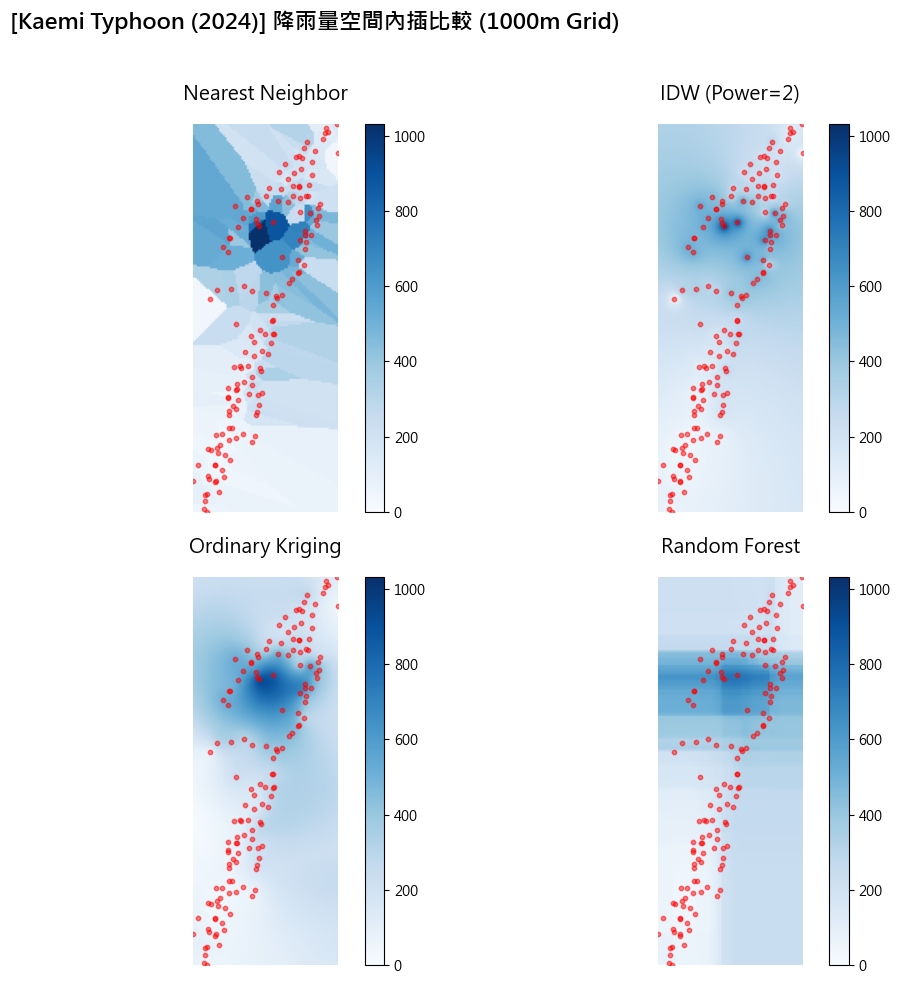

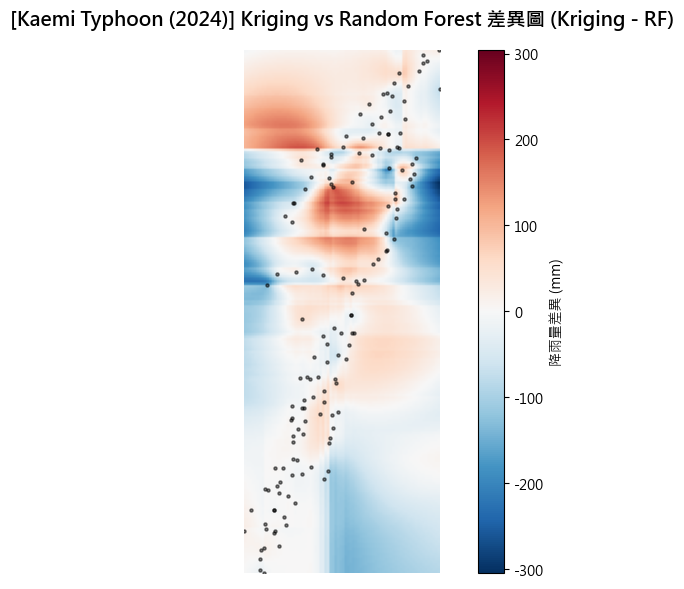

🚀 開始執行 Bamboo Typhoon (2025) 的內插擂台賽...
   [1/4] 計算 Nearest Neighbor...
   [2/4] 計算 IDW...
   [3/4] 計算 Ordinary Kriging...
   [4/4] 計算 Random Forest...


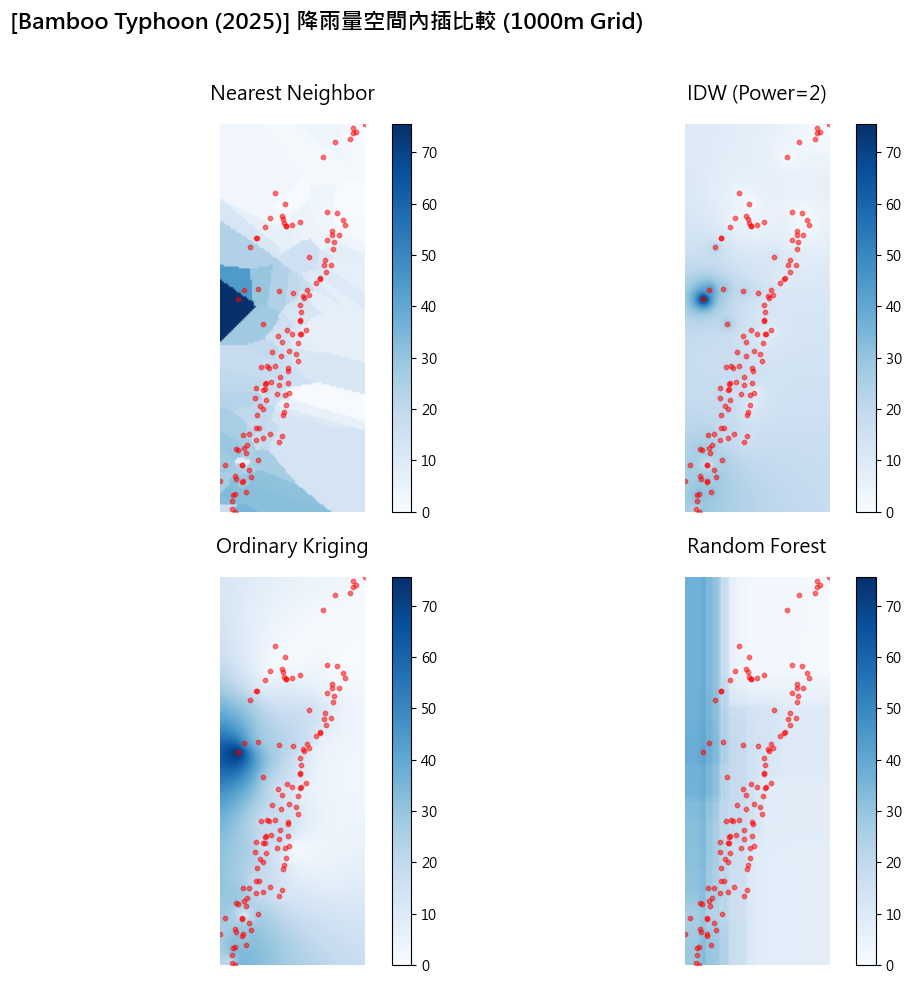

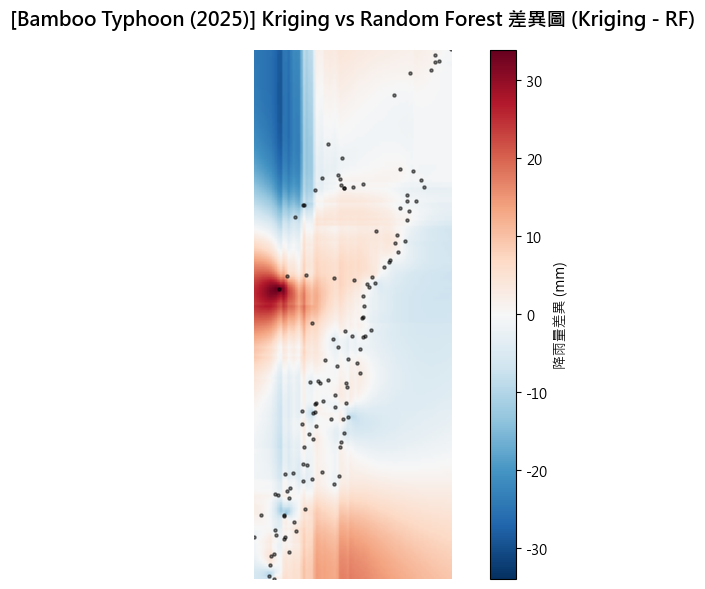

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestRegressor

def run_interpolation_shootout(gdf, value_col, ok_model, event_name):
    """
    執行 1000m 網格的四種內插方法比較，並繪製 2x2 比較圖與 Kriging vs RF 差異圖。
    """
    print(f"🚀 開始執行 {event_name} 的內插擂台賽...")
    
    # 1. 建立 1000m 解析度網格
    minx, miny, maxx, maxy = gdf.total_bounds
    # 確保網格涵蓋整個範圍，並以 1000 為間隔
    grid_x = np.arange(minx, maxx, 1000)
    grid_y = np.arange(miny, maxy, 1000)
    xx, yy = np.meshgrid(grid_x, grid_y)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # 準備觀測資料
    obs_x = gdf['Easting'].values
    obs_y = gdf['Northing'].values
    obs_z = gdf[value_col].values
    
    # --- 方法 1: Nearest Neighbor ---
    print("   [1/4] 計算 Nearest Neighbor...")
    nn_interp = NearestNDInterpolator(list(zip(obs_x, obs_y)), obs_z)
    z_nn = nn_interp(xx, yy)
    
    # --- 方法 2: IDW (Inverse Distance Weighting, power=2) ---
    print("   [2/4] 計算 IDW...")
    dist = cdist(grid_points, np.column_stack((obs_x, obs_y)))
    dist[dist == 0] = 1e-10 # 避免除以零
    weights = 1.0 / (dist ** 2)
    z_idw_flat = np.sum(weights * obs_z, axis=1) / np.sum(weights, axis=1)
    z_idw = z_idw_flat.reshape(xx.shape)
    
    # --- 方法 3: Ordinary Kriging ---
    print("   [3/4] 計算 Ordinary Kriging...")
    z_krige, ss_krige = ok_model.execute('grid', grid_x, grid_y)
    z_krige = z_krige.data # 去除 mask 確保為 numpy array
    
    # --- 方法 4: Random Forest ---
    print("   [4/4] 計算 Random Forest...")
    rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=42)
    rf.fit(np.column_stack((obs_x, obs_y)), obs_z)
    z_rf = rf.predict(grid_points).reshape(xx.shape)
    
    # ================= 繪圖視覺化 =================
    extent = [minx, maxx, miny, maxy]
    
    # (1) 2x2 四種方法比較圖
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    # 🚨 修改點 1：拿掉 y 參數，讓它自動排版
    fig.suptitle(f'[{event_name}] 降雨量空間內插比較 (1000m Grid)', fontsize=16, fontweight='bold')
    
    methods = [
        ('Nearest Neighbor', z_nn), ('IDW (Power=2)', z_idw),
        ('Ordinary Kriging', z_krige), ('Random Forest', z_rf)
    ]
    
    for ax, (title, z_data) in zip(axes.flatten(), methods):
        im = ax.imshow(z_data, origin='lower', extent=extent, cmap='Blues', vmin=0, vmax=np.max(obs_z))
        ax.set_title(title, fontsize=14)
        ax.scatter(obs_x, obs_y, c='red', s=10, alpha=0.5) 
        ax.axis('off') 
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
    # 🚨 修改點 2：加入 rect 參數，保留上方 4% 的空間給主標題
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # (2) Kriging vs Random Forest 差異圖
    plt.figure(figsize=(8, 6))
    z_diff = z_krige - z_rf
    max_diff = max(abs(np.nanmin(z_diff)), abs(np.nanmax(z_diff))) 
    
    plt.title(f'[{event_name}] Kriging vs Random Forest 差異圖 (Kriging - RF)', fontsize=14, fontweight='bold')
    im_diff = plt.imshow(z_diff, origin='lower', extent=extent, cmap='RdBu_r', vmin=-max_diff, vmax=max_diff)
    plt.scatter(obs_x, obs_y, c='black', s=5, alpha=0.5)
    plt.colorbar(im_diff, label='降雨量差異 (mm)')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return {
        'grid_x': grid_x, 'grid_y': grid_y, 
        'z_krige': z_krige, 'ss_krige': ss_krige.data, 'z_rf': z_rf
    }

# ================= 執行區塊 =================
# 假設你前面的 Variogram 模型變數叫做 kaemi_ok_sph 和 bamboo_ok_exp
# 執行凱米颱風
kaemi_results = run_interpolation_shootout(gdf_kaemi, target_column, kaemi_ok_sph, 'Kaemi Typhoon (2024)')

# 執行竹節草颱風
bamboo_results = run_interpolation_shootout(gdf_bamboo, target_column, bamboo_ok_exp, 'Bamboo Typhoon (2025)')

> 📝 **Captain's Log: Phase 4 - 信心指標與成果封裝 (Uncertainty Analysis & GeoTIFF Export)**
> 
> **任務目標**：產出 Kriging 的不確定性地圖 (Sigma Map)，並將最終的預測成果導出為符合業界標準的 GeoTIFF 格式，供後續 GIS 軟體使用。
> 
> **執行動作 (AI 協助紀錄)**：
> 1. **信心偵測 (Sigma Map)**：提取 Kriging 計算過程中伴隨產生的 Variance (變異量)，並開根號得到標準差 (Sigma)。這張圖能直觀地告訴我們，在哪些區域（通常是測站稀疏處）內插結果的可靠性較低。
> 2. **座標翻轉處理**：由於 `numpy` 陣列的索引順序（由上而下）與地理座標系統的 Y 軸方向（由下而上）相反，導出前必須執行 `np.flipud()`，否則地圖在 QGIS 或 ArcGIS 中會發生南北顛倒。
> 3. **格式化輸出**：使用 `rasterio` 庫，將內插結果矩陣封裝進 GeoTIFF 容器，並嚴格定義其投影座標系統 (EPSG:3826) 與空間範圍 (Transform)。

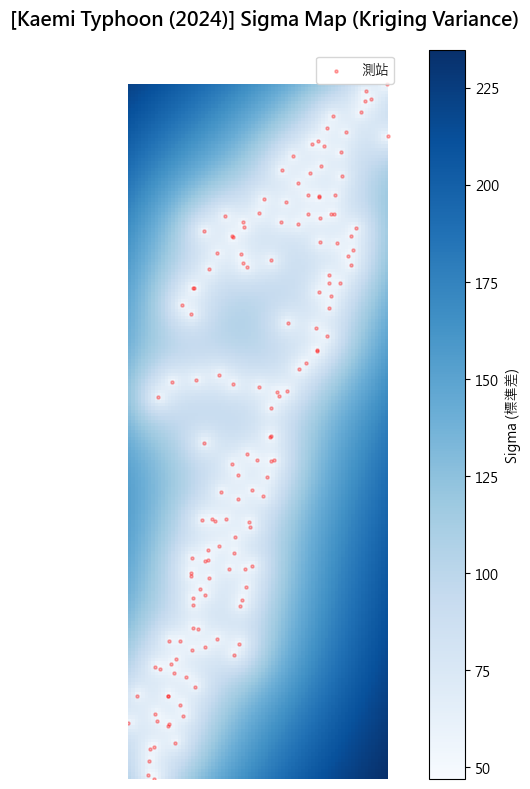

✅ 已成功導出: kaemi_rainfall.tif
✅ 已成功導出: kaemi_variance.tif
✅ 已成功導出: kaemi_rf_rainfall.tif


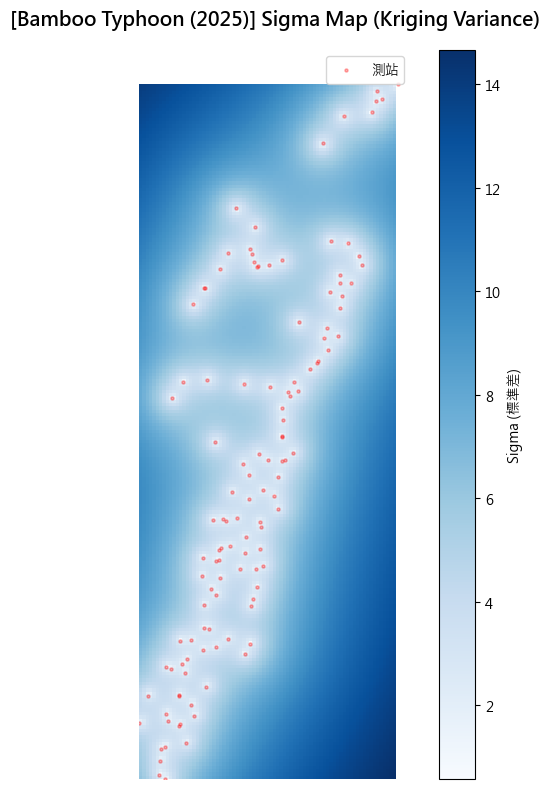

✅ 已成功導出: bamboo_rainfall.tif
✅ 已成功導出: bamboo_variance.tif
✅ 已成功導出: bamboo_rf_rainfall.tif


In [6]:
import rasterio
from rasterio.transform import from_origin

def analyze_uncertainty_and_export(results, gdf, event_name, export_prefix="kaemi"):
    """
    產出 Sigma Map 並將結果導出為 GeoTIFF 檔案。
    """
    grid_x = results['grid_x']
    grid_y = results['grid_y']
    z_krige = results['z_krige']
    ss_krige = results['ss_krige'] # Variance
    z_rf = results['z_rf']
    
    # --- 1. 繪製 Sigma Map (Kriging Variance 視覺化) ---
    sigma = np.sqrt(ss_krige) # 取標準差
    extent = [grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()]
    
    plt.figure(figsize=(6, 8))
    plt.title(f'[{event_name}] Sigma Map (Kriging Variance)', fontsize=14, fontweight='bold')
    im = plt.imshow(sigma, origin='lower', extent=extent, cmap='Blues')
    plt.scatter(gdf['Easting'], gdf['Northing'], c='red', s=5, alpha=0.3, label='測站')
    plt.colorbar(im, label='Sigma (標準差)')
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # --- 2. 導出 GeoTIFF (以 EPSG:3826 儲存) ---
    # 定義 Transform (解析度為 1000m)
    # 從網格左上角開始: [min_x, max_y]
    res = 1000
    transform = from_origin(grid_x.min(), grid_y.max(), res, res)
    
    def save_tif(data, filename):
        # 🚨 指揮官提醒：GeoTIFF row 0 = North，但 numpy row 0 = South，必須翻轉！
        output_data = np.flipud(data).astype('float32')
        
        with rasterio.open(
            filename, 'w',
            driver='GTiff',
            height=output_data.shape[0],
            width=output_data.shape[1],
            count=1,
            dtype=output_data.dtype,
            crs='EPSG:3826',
            transform=transform,
        ) as dst:
            dst.write(output_data, 1)
        print(f"✅ 已成功導出: {filename}")

    # 依照作業要求導出檔案 (可擇一事件執行，這裡以 export_prefix 區分)
    save_tif(z_krige, f"{export_prefix}_rainfall.tif")
    save_tif(sigma, f"{export_prefix}_variance.tif")
    save_tif(z_rf, f"{export_prefix}_rf_rainfall.tif")

# ================= 執行區塊 =================
# 你可以針對凱米颱風進行 Sigma Map 分析與導出
analyze_uncertainty_and_export(kaemi_results, gdf_kaemi, 'Kaemi Typhoon (2024)', export_prefix="kaemi")

# 同理，如果也需要竹節草的 Sigma Map：
analyze_uncertainty_and_export(bamboo_results, gdf_bamboo, 'Bamboo Typhoon (2025)', export_prefix="bamboo")